# Why does nothing correlate with potability?

**Water Quality dataset — 3,276 samples, 9 physico-chemical measurements, one binary
`Potability` label.**

My first pass ended with a chart that bothered me: every feature correlated with
`Potability` at |r| < 0.04, and I wrote underneath it *"I am wondering why???"* Then I
stopped. This notebook answers that. Three answers, and only the third is interesting.

1. **This is not drinkable water.** 99.9% of samples exceed the project document's limit
   for dissolved solids, 8% exceed seawater, and every non-null value in the file is
   distinct to 15 decimal places. Generated data, not laboratory data.
2. **The guideline bands mostly do not matter.** One of the eight — pH 6.5–8.5 — separates
   the classes, by 8 percentage points. The other seven do nothing.
3. **There is real signal, and correlation is structurally blind to it.** `Potability`
   depends on an *interaction*: water is labelled potable when pH and sulfate sit on
   **opposite** sides of their means. Their standardised product correlates −0.22 with the
   label, while the two ingredients correlate +0.014 and −0.015.

"No correlation" answers a far narrower question than the one I thought I was asking.

**Data source.** [Water Quality — drinking water potability](https://www.kaggle.com/datasets/adityakadiwal/water-potability),
Aditya Kadiwal, Kaggle, released CC0. The thresholds quoted throughout come from a briefing
document supplied with the assignment — they are **not** WHO or EPA limits, and several are
far stricter.

---
## 1. Setup

One split runs through the notebook: **potable** against **not potable**, fixed to a blue
and a brown in every chart. That pair has a lightness ratio of 2.6 and stays separated
under simulated deuteranopia, protanopia and greyscale.

Green and red are annotation only — "inside the document's range" and "outside it" — and
every band drawn in them carries a text label too. The sequential ramp is used once, the
diverging ramp once, centred on the 39% base rate.

In [11]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle
from matplotlib.ticker import FuncFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import plotly.graph_objects as go
import plotly.io as pio

# Pulls plotly.js from a CDN instead of embedding it. Keeps the committed .ipynb small
# and the charts stay interactive on Kaggle.
pio.renderers.default = "notebook_connected"

RANDOM_SEED = 7
rng = np.random.default_rng(RANDOM_SEED)

FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(exist_ok=True)


# Path to the CSV. On Kaggle this is what the Input sidebar's "Copy file path"
# button gives for the attached dataset; locally it is the file next to the notebook.
# Kaggle mounts attached datasets under /kaggle/input; locally the CSV sits next to the notebook.
DATA_PATH = ("/kaggle/input/datasets/adityakadiwal/water-potability/water_potability.csv"
             if Path("/kaggle/input").exists() else "water_potability.csv")
# DATA_PATH = "water_potability.csv"


# ---------------------------------------------------------------- palette ----
# Declared once. A class keeps its colour for the entire notebook.
C = {
    "potable":     "#99C2FF",   # class 1
    "not_potable": "#9D6638",   # class 0
    "ok":          "#59A14F",   # annotation only: inside the document's range
    "not_ok":      "#E15759",   # annotation only: outside it
    "boundary":    "#161111",   # threshold lines
    "text":        "#2B2B2B",
    "grid":        "#DDDDDD",
    "neutral":     "#9E9E9E",   # context, un-highlighted series
}

CLASS_COLOR = {0: C["not_potable"], 1: C["potable"]}
CLASS_LABEL = {0: "Not potable", 1: "Potable"}

# Sequential: potability rate over a grid, low to high.
SEQ = LinearSegmentedColormap.from_list("seq", ["#F7F4F1", C["not_potable"]])
# Diverging: the same rate, centred on the base rate.
DIV = LinearSegmentedColormap.from_list("div", [C["not_potable"], "#F5F2EF", "#3B6CA8"])

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "axes.grid": True,
    "axes.grid.axis": "y",
    "axes.axisbelow": True,          # gridlines behind the data, never through it
    "grid.color": C["grid"],
    "grid.linewidth": 0.7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#BBBBBB",
    "axes.titlesize": 13,
    "axes.titleweight": "semibold",
    "axes.titlelocation": "left",
    "axes.labelcolor": C["text"],
    "text.color": C["text"],
    "font.size": 11,
})

PLOTLY_LAYOUT = dict(
    template="simple_white",
    font=dict(size=13, color=C["text"]),
    title_x=0.02,
    title_xanchor="left",
    title_font=dict(size=16),
    margin=dict(l=70, r=40, t=95, b=60),
)



def titled(ax, title, subtitle=None):
    """Bold left-aligned title with an optional grey subtitle underneath it.

    matplotlib has no subtitle, and placing one with ax.text collides with the title
    unless the title is padded first. Doing it in one place keeps every chart aligned.
    """
    ax.set_title(title, pad=26 if subtitle else 12)
    if subtitle:
        ax.text(0, 1.015, subtitle, transform=ax.transAxes,
                fontsize=9.5, color="#666666", va="bottom")


def thousands(x, _pos=None):
    """Axis tick formatter: 20000 -> 20,000. Avoids matplotlib's 1e4 notation."""
    return f"{x:,.0f}"

---
## 2. The data, and what the columns are supposed to mean

Every threshold the project document specifies lives in one `GUIDELINES` dictionary, so
each threshold line drawn later reads from a single place.

| Column | Meaning | Document's acceptable range |
|---|---|---|
| `ph` | acidity / alkalinity, 0–14 | 6.5 – 8.5 |
| `Hardness` | dissolved calcium and magnesium, mg/L | not specified |
| `Solids` | total dissolved solids, mg/L | ideal 500, maximum 1000 |
| `Chloramines` | disinfectant residual, mg/L | maximum 4 |
| `Sulfate` | dissolved sulfate, mg/L | usual 3–30, maximum 1000 |
| `Conductivity` | electrical conductivity, μS/cm | maximum 400 |
| `Organic_carbon` | total organic carbon, mg/L | maximum 2 filtered, 4 reservoir |
| `Trihalomethanes` | disinfection by-product, μg/L | maximum 80 |
| `Turbidity` | cloudiness, NTU | maximum 5 |
| `Potability` | **target**: 1 = safe to drink | — |

In [12]:
df = pd.read_csv(DATA_PATH)

FEATURES = [c for c in df.columns if c != "Potability"]
TARGET = "Potability"
BASE_RATE = df[TARGET].mean()

# (lower, upper, label) for every band the document specifies. None = no bound given.
GUIDELINES = {
    "ph":              (6.5, 8.5, "Acceptable pH: 6.5-8.5"),
    "Solids":          (None, 1000, "Max total dissolved solids: 1,000 mg/L"),
    "Chloramines":     (None, 4, "Max chloramines: 4 mg/L"),
    "Sulfate":         (None, 1000, "Max sulfate: 1,000 mg/L"),
    "Conductivity":    (None, 400, "Max conductivity: 400 uS/cm"),
    "Organic_carbon":  (None, 2, "Max organic carbon (filtered): 2 mg/L"),
    "Trihalomethanes": (None, 80, "Max trihalomethanes: 80 ug/L"),
    "Turbidity":       (None, 5, "Max turbidity: 5 NTU"),
}

UNITS = {
    "ph": "", "Hardness": "mg/L", "Solids": "mg/L", "Chloramines": "mg/L",
    "Sulfate": "mg/L", "Conductivity": "uS/cm", "Organic_carbon": "mg/L",
    "Trihalomethanes": "ug/L", "Turbidity": "NTU",
}

print(f"{df.shape[0]:,} samples x {len(FEATURES)} features")
print(f"Potable {BASE_RATE:.1%}   Not potable {1 - BASE_RATE:.1%}")
print("\nMissing values:")
print(df[FEATURES].isna().sum()[lambda s: s > 0].to_string())

3,276 samples x 9 features
Potable 39.0%   Not potable 61.0%

Missing values:
ph                 491
Sulfate            781
Trihalomethanes    162


---
## 3. Is this water?

Before analysing the label: are the measurements physically sensible? Two checks, the
**magnitude** of the values and their **precision**. The second is decisive, and not one I
thought to run the first time.

In [13]:
solids = df["Solids"]
thresholds = [(500, "the document's ideal"),
              (1_000, "the document's maximum"),
              (35_000, "roughly seawater")]

magnitude = pd.DataFrame({
    "threshold (mg/L)": [t for t, _ in thresholds],
    "meaning": [m for _, m in thresholds],
    "samples above": [(solids > t).sum() for t, _ in thresholds],
})
magnitude["% of file"] = (magnitude["samples above"] / len(df) * 100).round(1)

print("Total dissolved solids")
print(f"  range {solids.min():,.0f} to {solids.max():,.0f} mg/L, "
      f"median {solids.median():,.0f}\n")
print(magnitude.to_string(index=False))

sulfate = df["Sulfate"].dropna()
print(f"\nSulfate")
print(f"  range {sulfate.min():.0f} to {sulfate.max():.0f} mg/L, "
      f"median {sulfate.median():.0f}")
print(f"  samples inside the document's 'usual' 3-30 mg/L band: "
      f"{((sulfate >= 3) & (sulfate <= 30)).sum()}")
print(f"  samples above the 1,000 mg/L maximum: {(sulfate > 1000).sum()}")

Total dissolved solids
  range 321 to 61,227 mg/L, median 20,928

 threshold (mg/L)                meaning  samples above  % of file
              500   the document's ideal           3275      100.0
             1000 the document's maximum           3274       99.9
            35000       roughly seawater            268        8.2

Sulfate
  range 129 to 481 mg/L, median 333
  samples inside the document's 'usual' 3-30 mg/L band: 0
  samples above the 1,000 mg/L maximum: 0


In [14]:
# Precision fingerprint. Instruments round; random number generators do not.
precision = pd.DataFrame({
    "non-null rows": [df[c].notna().sum() for c in FEATURES],
    "distinct values": [df[c].nunique() for c in FEATURES],
    "median decimal places": [
        int(df[c].dropna().astype(str).str.split(".").str[-1].str.len().median())
        for c in FEATURES
    ],
}, index=FEATURES)
precision["every value distinct?"] = np.where(
    precision["distinct values"] == precision["non-null rows"], "yes", "no")
precision

,non-null rows,distinct values,median decimal places,every value distinct?
ph,2785,2785,15,yes
Hardness,3276,3276,14,yes
Solids,3276,3276,12,yes
Chloramines,3276,3276,15,yes
Sulfate,2495,2495,13,yes
Conductivity,3276,3276,13,yes
Organic_carbon,3276,3276,15,yes
Trihalomethanes,3114,3114,14,yes
Turbidity,3276,3276,15,yes


**Takeaway — this file was generated, not measured.**

Every column carries a median of 12 to 15 decimal places, and in every column *every
non-null value is distinct*. A pH meter reports 7.2, not 7.203164927481950. Real
measurements round, repeat and pile up on instrument-preferred values. These are float64
draws from a random number generator.

The magnitudes agree: dissolved solids run from 321 to 61,227 mg/L with a median of 20,928,
so **99.9% of samples exceed the document's 1,000 mg/L maximum and 8% exceed the
concentration of seawater**. Sulfate clears its ceiling but puts *no sample at all* inside
the "usual" 3–30 mg/L band.

My first pass blamed a unit error. It is not one — the numbers were never measurements.
Everything below therefore describes **how this file was constructed**, not real water.

---
## 4. Missingness

`ph` (15.0%), `Sulfate` (23.8%) and `Trihalomethanes` (4.9%) have missing values, all
genuine `NaN`. What decides the cleaning strategy is not how many are missing but whether
they go missing **together**, so I count them per row.

In [15]:
def missing_pattern_summary(df, columns):
    """
    Summarize the number of missing values per row for selected columns.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    columns : list
        List of column names to inspect.

    Returns
    -------
    pd.DataFrame
        Summary dataframe with:
        - Number of Missing Features
        - Number of Rows
        - Percent of Rows
    """
    missing_per_row = df[columns].isna().sum(axis=1)

    summary = (
        missing_per_row
        .value_counts()
        .sort_index()
        .rename_axis("Number of Missing Features")
        .reset_index(name="Number of Rows")
    )

    summary["Percent of Rows"] = (
        summary["Number of Rows"] / len(df) * 100
    ).round(2)

    return summary


MISSING_COLUMNS = ["ph", "Sulfate", "Trihalomethanes"]
display(missing_pattern_summary(df, MISSING_COLUMNS))

print("Which combination goes missing, and how often:")
pattern = (df[MISSING_COLUMNS].isna()
             .apply(lambda row: tuple(row.index[row]), axis=1)
             .value_counts())
print(pattern.to_string())

,Number of Missing Features,Number of Rows,Percent of Rows
0,0,2011,61.39
1,1,1105,33.73
2,2,151,4.61
3,3,9,0.27


Which combination goes missing, and how often:
()                                2011
(Sulfate,)                         638
(ph,)                              362
(Trihalomethanes,)                 105
(ph, Sulfate)                      103
(Sulfate, Trihalomethanes)          31
(ph, Trihalomethanes)               17
(ph, Sulfate, Trihalomethanes)       9


**Takeaway.** The three columns go missing largely independently: 2,011 rows (61.4%) are
complete, 1,105 are missing one value, 151 are missing two, and only 9 are missing all
three. There is no block of rows where the measurement was simply never taken.

### Is the missingness related to the label?

This decides whether dropping rows is safe, and I did not ask it in my first pass. If
values go missing more often in one class than the other, every row I delete shifts the
class balance and quietly biases everything downstream.

In [16]:
from scipy.stats import chi2_contingency

rows = []
for column in MISSING_COLUMNS:
    table = pd.crosstab(df[column].isna(), df[TARGET])
    _, p_value, _, _ = chi2_contingency(table)
    by_class = df.groupby(TARGET)[column].apply(lambda s: s.isna().mean() * 100)
    rows.append({
        "column": column,
        "missing % | not potable": round(by_class[0], 1),
        "missing % | potable": round(by_class[1], 1),
        "difference (pp)": round(by_class[1] - by_class[0], 1),
        "chi-squared p": round(p_value, 3),
    })

pd.DataFrame(rows).set_index("column")

,missing % | not potable,missing % | potable,difference (pp),chi-squared p
column,,,,
ph,15.7,13.8,-1.9,0.159
Sulfate,24.4,22.9,-1.5,0.348
Trihalomethanes,5.4,4.3,-1.1,0.203


**Takeaway.** The rates differ between the classes by 1.1 to 1.9 percentage points, and
none of the three differences is distinguishable from chance (p = 0.16, 0.35, 0.20) —
missing completely at random with respect to `Potability`.

Dropping rows is still information thrown away, but the deleted rows are not a biased
sample of the label, so every group comparison below survives the cut.

In [17]:
# The cleaning from my first pass, unchanged: drop the 9 rows missing all three
# columns, then drop every row still missing Trihalomethanes.
df_new = df.drop(df[df[MISSING_COLUMNS].isna().all(axis=1)].index)
df_new = df_new[df_new["Trihalomethanes"].notna()].copy()

print(f"Original:   {len(df):,} rows")
print(f"After:      {len(df_new):,} rows")
print(f"Cost:       {len(df) - len(df_new)} rows "
      f"({(1 - len(df_new) / len(df)) * 100:.1f}%), with all nine features kept")
print(f"Potable rate: {df[TARGET].mean():.4f} -> {df_new[TARGET].mean():.4f}")

Original:   3,276 rows
After:      3,114 rows
Cost:       162 rows (4.9%), with all nine features kept
Potable rate: 0.3901 -> 0.3927


### Imputing `ph` and `Sulfate`

I wrote the k-nearest-neighbours imputer by hand rather than importing `KNNImputer`, to
understand what the method actually does. It contains a bug worth keeping on the page
rather than quietly replacing.

In [18]:
def simple_knn_impute(df, target_col, k=10, debug=True, debug_samples=2):
    # df = main data | target_col = with missing value | k = number of neighbors
    df = df.copy()
    feature_cols = [
        col for col in df.columns                                # all of columns
        if col != target_col and df[col].isna().sum() == 0       # skip other gaps
    ]

    shown = 0

    known = df[df[target_col].notna()]
    missing = df[df[target_col].isna()]

    for idx, row in missing.iterrows():                          # idx = index | row = the row

        diffs = known[feature_cols].sub(row[feature_cols]).abs()

        distances = diffs.sum(axis=1)                            # Manhattan distance (L1)

        nearest_idx = distances.nsmallest(k).index               # k nearest neighbors

        imputed_value = known.loc[nearest_idx, target_col].mean()

        df.at[idx, target_col] = imputed_value

        if debug and shown < debug_samples:
            print(f"Missing sample index: {idx}")
            print(f"Imputed value for '{target_col}': {imputed_value:.4f}")
            print(f"Neighbour values: {known.loc[nearest_idx, target_col].round(3).values}")
            shown += 1

    return df

### The bug: an unscaled distance is a one-column distance

`distances = diffs.sum(axis=1)` adds raw differences across columns measured on wildly
different scales. Two samples differing by 3,000 mg/L of dissolved solids and 0.4 units of
pH are 3000.4 apart, of which pH supplies 0.013%.

So how much of that distance does each column actually contribute? Each column's mean
absolute deviation estimates a typical difference in it, so the shares answer it directly.

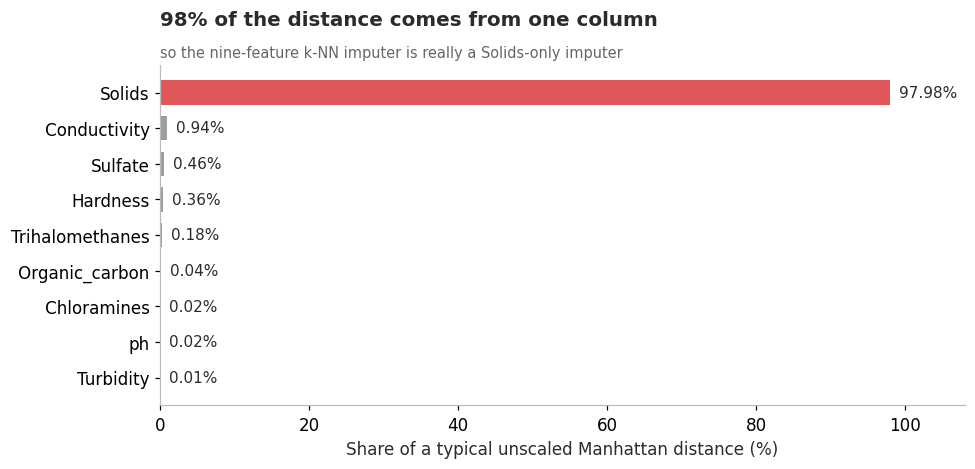

In [19]:
donors = df_new.dropna()
typical_difference = donors[FEATURES].apply(lambda c: (c - c.median()).abs().mean())
distance_share = (typical_difference / typical_difference.sum() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4.4))
order = distance_share.index[::-1]
bar_colors = [C["not_ok"] if f == "Solids" else C["neutral"] for f in order]
ax.barh(range(len(order)), distance_share[order].values, color=bar_colors, height=0.68)
for i, feature in enumerate(order):
    value = distance_share[feature]
    ax.text(value + 1.2, i, f"{value:.2f}%", va="center", fontsize=10)

ax.set_yticks(range(len(order)), order)
ax.set_xlim(0, 108)
ax.set_xlabel("Share of a typical unscaled Manhattan distance (%)")
titled(ax, "98% of the distance comes from one column",
       "so the nine-feature k-NN imputer is really a Solids-only imputer")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "01-knn-distance-share.png")
plt.show()

**Takeaway.** `Solids` contributes **98.0%** of the distance and `ph` contributes
**0.02%**. My "k-nearest-neighbours over nine features" imputer was selecting the ten rows
with the closest `Solids` value and averaging their pH — and section 3 showed `Solids` is
drawn independently of everything else. Those were not neighbours in any meaningful sense.

The fix is one line: standardise before measuring distance. Both versions run below,
because "the code was wrong" is a weaker claim than "here is how much it mattered".

In [20]:
def knn_impute_scaled(df, target_col, k=10):
    """As simple_knn_impute, but distances are measured on standardised columns.

    Each donor column is converted to z-scores first, so a 1-standard-deviation
    difference costs the same regardless of the column's unit.
    """
    df = df.copy()
    feature_cols = [c for c in df.columns
                    if c != target_col and df[c].isna().sum() == 0]

    scaled = df[feature_cols]
    scaled = (scaled - scaled.mean()) / scaled.std()

    known_mask = df[target_col].notna()
    known_scaled = scaled[known_mask]
    known_target = df.loc[known_mask, target_col]

    for idx in df.index[~known_mask]:
        distances = known_scaled.sub(scaled.loc[idx]).abs().sum(axis=1)
        nearest_idx = distances.nsmallest(k).index
        df.at[idx, target_col] = known_target.loc[nearest_idx].mean()

    return df


df_unscaled = simple_knn_impute(df_new, "ph", debug=False)
df_unscaled = simple_knn_impute(df_unscaled, "Sulfate", debug=False)

df_scaled = knn_impute_scaled(df_new, "ph")
df_scaled = knn_impute_scaled(df_scaled, "Sulfate")

comparison = []
for column in ("ph", "Sulfate"):
    was_missing = df_new[column].isna()
    a = df_unscaled.loc[was_missing, column]
    b = df_scaled.loc[was_missing, column]
    observed = df_new[column].dropna()
    comparison.append({
        "column": column,
        "values imputed": int(was_missing.sum()),
        "observed sd": round(observed.std(), 3),
        "unscaled: sd of fills": round(a.std(), 3),
        "scaled: sd of fills": round(b.std(), 3),
        "mean |difference|": round((a - b).abs().mean(), 3),
    })

print("Both imputers produce a value for every gap. The question is how varied "
      "those values are:\n")
print(pd.DataFrame(comparison).to_string(index=False))

Both imputers produce a value for every gap. The question is how varied those values are:

 column  values imputed  observed sd  unscaled: sd of fills  scaled: sd of fills  mean |difference|
     ph             465        1.585                  0.540                0.596              0.623
Sulfate             741       41.421                 15.081               14.539             15.060


**Takeaway.** Both versions fill every gap, and the filled values differ by **0.62 pH
units** and **15 mg/L** of sulfate on average.

The **spread** is the more interesting column. Any k-NN imputer averages k donors, so its
output is always less variable than the real column: 0.54–0.60 here against an observed pH
standard deviation of 1.59. That shrinkage is inherent to imputation, not a symptom of the
bug — and both versions shrink by nearly the same amount. **The fix does not announce
itself in these numbers**, which is much of why the bug survived my first pass. The
argument for the scaled version is not that its output looks different; it is that its
donors are chosen on a defensible criterion.

Neither version invents signal: everything from section 6 onward runs on **complete cases
only**, so no conclusion rests on an imputed value.

In [21]:
# Everything from here on uses the scaled imputer.
df_no_missing = df_scaled
assert df_no_missing[FEATURES].isna().sum().sum() == 0

complete_cases = df.dropna().copy()

print(f"Imputed frame (for plotting):  {len(df_no_missing):,} rows")
print(f"Complete cases (for modelling): {len(complete_cases):,} rows")

Imputed frame (for plotting):  3,114 rows
Complete cases (for modelling): 2,011 rows


---
## 5. The guideline bands

This is the part of my first pass I am happiest with. For each feature I drew the
document's acceptable range onto a scatter against pH and asked whether the potable samples
fell inside it. If `Potability` means anything, they should.

What I did not do was **measure** the answer — every note under those plots ended in a
question where two lines of arithmetic would have settled it. The plots are all here, each
now with a number attached.

In [22]:
def plot_scatter(df, y_col, x_col="ph", target_col="Potability", ax=None):
    """
    Scatter plot of two features colored by target class.

    Returns
    -------
    fig, ax : matplotlib figure and axis objects
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    else:
        fig = ax.figure

    for cls in (0, 1):
        subset = df[df[target_col] == cls]
        ax.scatter(
            subset[x_col], subset[y_col],
            color=CLASS_COLOR[cls],
            label=CLASS_LABEL[cls],
            alpha=0.7,
            s=18,
            linewidths=0,
        )

    unit = f" ({UNITS[y_col]})" if UNITS.get(y_col) else ""
    ax.set_xlabel("pH")
    ax.set_ylabel(f"{y_col}{unit}")
    ax.legend(frameon=False, loc="upper right")
    ax.grid(False)

    return fig, ax


def ph_band(ax, label=True):
    """Draw the document's acceptable pH window onto an axis."""
    low, high, _ = GUIDELINES["ph"]
    ax.axvline(low, color=C["boundary"], linestyle="--", linewidth=1.1)
    ax.axvline(high, color=C["boundary"], linestyle="--", linewidth=1.1)
    if label:
        ax.axvspan(low, high, color=C["ok"], alpha=0.18, zorder=0)

### Hardness against pH

The green band is the only region where, on these two features alone, the document says
we should see potable water at all.

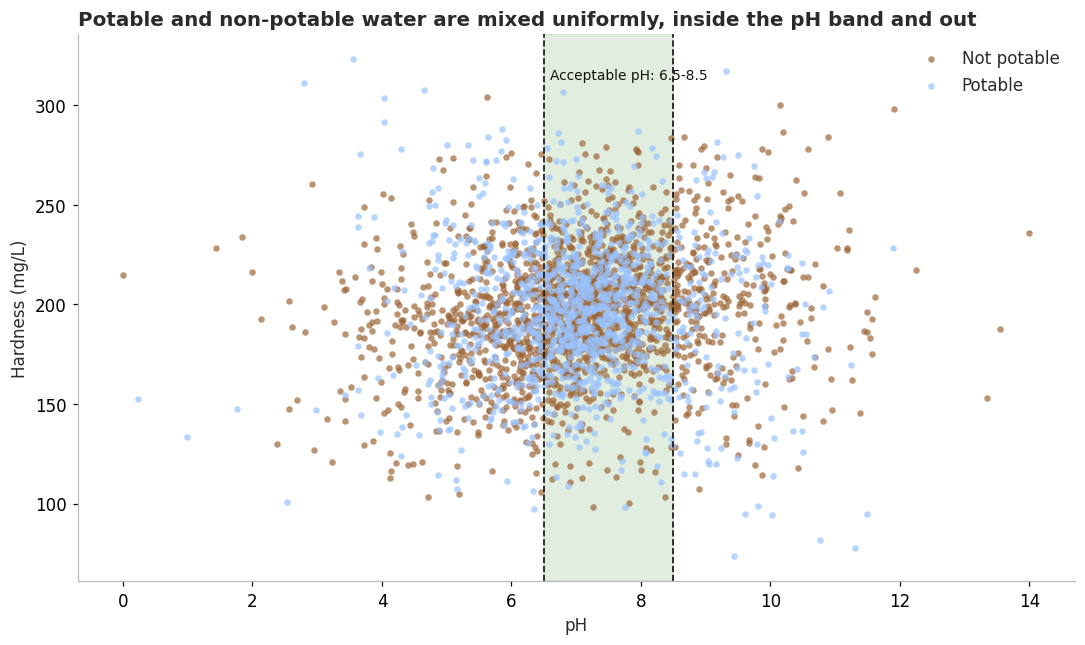

In [23]:
fig, ax = plot_scatter(df_no_missing, y_col="Hardness")
ph_band(ax)
ax.text(6.6, ax.get_ylim()[1] * 0.95, "Acceptable pH: 6.5-8.5",
        fontsize=9, color=C["boundary"], va="top")
ax.set_title("Potable and non-potable water are mixed uniformly, inside the pH band and out")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "02-hardness-vs-ph.png")
plt.show()

**Takeaway.** The classes are interleaved everywhere; no corner of this plane is
predominantly one class, inside the acceptable pH window or outside it. That shows **no
straight boundary on these two axes separates the classes** — not that the features are
uninformative, which is a different claim and one section 7 overturns.

### Solids against pH

The document sets the ideal level of dissolved solids at 500 mg/L and the maximum at 1,000.
The inset shows that region at the scale the document assumes.

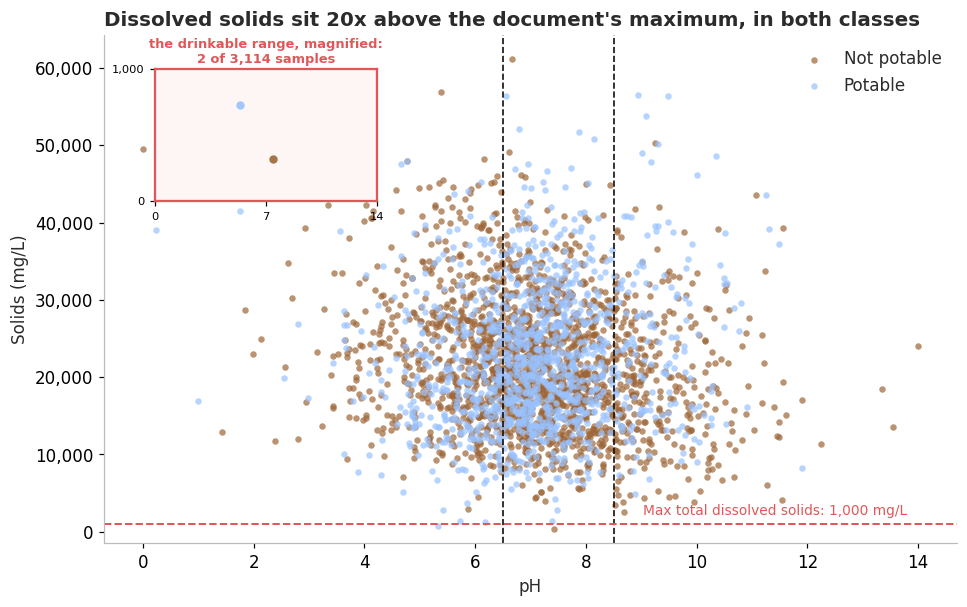

Samples at or below the 1,000 mg/L maximum: 2 of 3,114


In [24]:
fig, ax = plot_scatter(df_no_missing, y_col="Solids")
ph_band(ax, label=False)

_, solids_max, solids_label = GUIDELINES["Solids"]
ax.axhline(solids_max, color=C["not_ok"], linestyle="--", linewidth=1.3)
ax.text(13.8, solids_max + 1200, solids_label, color=C["not_ok"], fontsize=9, ha="right")
ax.yaxis.set_major_formatter(FuncFormatter(thousands))
ax.set_ylim(-1500, ax.get_ylim()[1])

# Inset: the same two axes, cropped to the range the document calls drinkable.
n_drinkable = int((df_no_missing["Solids"] <= solids_max).sum())
ax_inset = inset_axes(ax, width="26%", height="26%", loc="upper left",
                      bbox_to_anchor=(0.05, -0.05, 1, 1), bbox_transform=ax.transAxes)
ax_inset.set_facecolor("#FDF6F5")
for cls in (0, 1):
    subset = df_no_missing[df_no_missing["Potability"] == cls]
    ax_inset.scatter(subset["ph"], subset["Solids"],
                     color=CLASS_COLOR[cls], alpha=0.9, s=30, linewidths=0, zorder=3)
ax_inset.set_ylim(0, solids_max)
ax_inset.set_xlim(0, 14)
ax_inset.set_xticks([0, 7, 14])
ax_inset.set_yticks([0, solids_max])
ax_inset.set_yticklabels(["0", "1,000"])
ax_inset.tick_params(labelsize=7.5)
ax_inset.set_title(f"the drinkable range, magnified:\n{n_drinkable} of "
                   f"{len(df_no_missing):,} samples",
                   fontsize=8.5, loc="center", pad=4, color=C["not_ok"])
ax_inset.grid(False)
for spine in ax_inset.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor(C["not_ok"])
    spine.set_linewidth(1.5)

ax.set_title("Dissolved solids sit 20x above the document's maximum, in both classes")
# No tight_layout here: inset_axes is not compatible with it and warns. The figure is
# already correctly laid out, and savefig's bbox="tight" handles the margins.
plt.savefig(FIGURE_DIR / "03-solids-vs-ph.png")
plt.show()

print(f"Samples at or below the 1,000 mg/L maximum: "
      f"{(df_no_missing['Solids'] <= 1000).sum()} of {len(df_no_missing):,}")

**Takeaway.** The inset is nearly empty: two samples out of 3,114 fall inside the range
the document describes, and the main panel sits entirely above it. The threshold is not
separating good water from bad, it is sitting at the very bottom of the data. If I could
keep one plot from this notebook, it would be this one.

### Chloramines against pH

Here the acceptable region is a rectangle: pH between 6.5 and 8.5, **and** chloramines
below 4 mg/L.

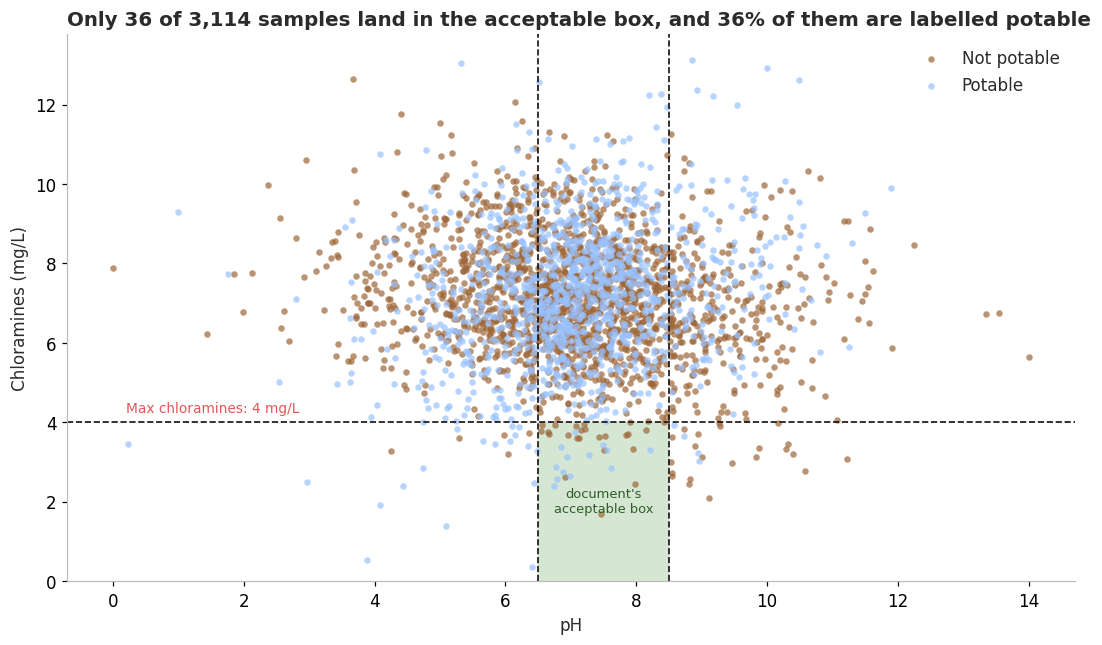

Inside the box:  n =  36, potable 36.1%
Outside the box: n = 3078, potable 39.3%
Base rate across the whole file: 39.0%


In [25]:
fig, ax = plot_scatter(df_no_missing, y_col="Chloramines")
ph_band(ax, label=False)

low, high, _ = GUIDELINES["ph"]
_, chlor_max, chlor_label = GUIDELINES["Chloramines"]
ax.axhline(chlor_max, color=C["boundary"], linestyle="--", linewidth=1.1)
ax.text(0.2, chlor_max + 0.25, chlor_label, fontsize=9, color=C["not_ok"])
ax.set_ylim(bottom=0)

ax.add_patch(Rectangle((low, 0), high - low, chlor_max,
                       facecolor=C["ok"], edgecolor="none", alpha=0.25, zorder=0))
ax.text((low + high) / 2, chlor_max / 2, "document's\nacceptable box",
        fontsize=8.5, ha="center", va="center", color="#2F5D2A")

inside = (df_no_missing["ph"].between(low, high)
          & (df_no_missing["Chloramines"] <= chlor_max))
rate_inside = df_no_missing.loc[inside, "Potability"].mean()
ax.set_title(f"Only {inside.sum()} of {len(df_no_missing):,} samples land in the "
             f"acceptable box, and {rate_inside:.0%} of them are labelled potable")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "04-chloramines-vs-ph.png")
plt.show()

print(f"Inside the box:  n = {inside.sum():3d}, potable {rate_inside:.1%}")
print(f"Outside the box: n = {(~inside).sum():3d}, potable "
      f"{df_no_missing.loc[~inside, 'Potability'].mean():.1%}")
print(f"Base rate across the whole file: {BASE_RATE:.1%}")

**Takeaway.** My original note called it *"surprising that we have potable datapoints"*
above the chloramine limit. Measured, it is not: samples inside the acceptable box are
labelled potable at essentially the same rate as those outside. Note also how few land in
the box at all — as with `Solids`, the threshold sits at the edge of the data rather than
through the middle of it.

### Every band at once, as one interactive chart

Rather than repeat the same figure seven more times: one chart with a **dropdown for the
vertical axis**. The pH window and the selected feature's own threshold are drawn for each
choice, and the subtitle reports the potable rate inside and outside the band.

Hover for exact values, drag to zoom, double-click to reset.

In [26]:
scatter_features = [f for f in FEATURES if f != "ph"]
ph_low, ph_high, _ = GUIDELINES["ph"]

fig = go.Figure()

for feature in scatter_features:
    for cls in (0, 1):
        subset = df_no_missing[df_no_missing["Potability"] == cls]
        unit = f" {UNITS[feature]}" if UNITS.get(feature) else ""
        fig.add_trace(go.Scattergl(
            x=subset["ph"], y=subset[feature],
            mode="markers",
            name=CLASS_LABEL[cls],
            marker=dict(color=CLASS_COLOR[cls], size=5, opacity=0.7),
            visible=(feature == scatter_features[0]),
            hovertemplate=("pH %{x:.2f}<br>" + feature + " %{y:,.1f}" + unit
                           + "<br>" + CLASS_LABEL[cls] + "<extra></extra>"),
        ))


def band_shapes(feature):
    """Layout shapes: the pH window plus this feature's own threshold line."""
    shapes = [dict(type="rect", xref="x", yref="paper",
                   x0=ph_low, x1=ph_high, y0=0, y1=1,
                   fillcolor=C["ok"], opacity=0.16, line_width=0, layer="below")]
    bound = GUIDELINES.get(feature)
    if bound is not None and bound[1] is not None:
        shapes.append(dict(type="line", xref="paper", yref="y",
                           x0=0, x1=1, y0=bound[1], y1=bound[1],
                           line=dict(color=C["not_ok"], width=1.6, dash="dash")))
    return shapes


def band_summary(feature):
    """Potable rate inside vs outside this feature's acceptable band."""
    bound = GUIDELINES.get(feature)
    if bound is None or bound[1] is None:
        return "no threshold specified in the document"
    inside = df_no_missing[feature] <= bound[1]
    if inside.sum() == 0 or (~inside).sum() == 0:
        return f"every sample falls on one side of the {bound[1]:,g} threshold"
    return (f"potable {df_no_missing.loc[inside, 'Potability'].mean():.0%} "
            f"inside the band (n={inside.sum():,})  vs  "
            f"{df_no_missing.loc[~inside, 'Potability'].mean():.0%} outside "
            f"(n={(~inside).sum():,})")


buttons = []
for i, feature in enumerate(scatter_features):
    visible = [False] * (2 * len(scatter_features))
    visible[2 * i] = visible[2 * i + 1] = True
    unit = f" ({UNITS[feature]})" if UNITS.get(feature) else ""
    buttons.append(dict(
        label=feature,
        method="update",
        args=[{"visible": visible},
              {"yaxis.title.text": feature + unit,
               "shapes": band_shapes(feature),
               "title.text": (f"{feature} against pH<br>"
                              f"<sup>{band_summary(feature)}</sup>")}],
    ))

first = scatter_features[0]
fig.update_layout(
    **PLOTLY_LAYOUT,
    height=560,
    xaxis_title="pH",
    yaxis_title=first + (f" ({UNITS[first]})" if UNITS.get(first) else ""),
    title=dict(text=f"{first} against pH<br><sup>{band_summary(first)}</sup>"),
    shapes=band_shapes(first),
    legend=dict(orientation="h", yanchor="bottom", y=1.0, xanchor="right", x=1),
    updatemenus=[dict(buttons=buttons, direction="down", showactive=True,
                      x=0.0, xanchor="left", y=1.16, yanchor="top",
                      bgcolor="white", bordercolor=C["grid"])],
)
fig.show()

### Does *any* band predict the label?

The dropdown gives the answer one feature at a time. This table gives it all at once.

In [27]:
rows = []
for feature, (low, high, _) in GUIDELINES.items():
    series = df[[feature, TARGET]].dropna()
    lower = -np.inf if low is None else low
    upper = np.inf if high is None else high
    inside = series[feature].between(lower, upper)

    if inside.sum() == 0 or (~inside).sum() == 0:
        rows.append({"feature": feature, "band": f"{low or 0:g} - {high:g}",
                     "n inside": int(inside.sum()),
                     "potable % inside": np.nan, "potable % outside": np.nan,
                     "p": np.nan})
        continue

    _, p_value, _, _ = chi2_contingency(pd.crosstab(inside, series[TARGET]))
    rows.append({
        "feature": feature,
        "band": f"{low or 0:g} - {high:g}",
        "n inside": int(inside.sum()),
        "potable % inside": round(series.loc[inside, TARGET].mean() * 100, 1),
        "potable % outside": round(series.loc[~inside, TARGET].mean() * 100, 1),
        "p": round(p_value, 3),
    })

band_table = pd.DataFrame(rows).set_index("feature")
band_table["difference (pp)"] = (band_table["potable % inside"]
                                 - band_table["potable % outside"]).round(1)
print(f"Base rate: {BASE_RATE:.1%} potable\n")
display(band_table)

all_bands = np.ones(len(df), dtype=bool)
for feature, (low, high, _) in GUIDELINES.items():
    lower = -np.inf if low is None else low
    upper = np.inf if high is None else high
    all_bands &= df[feature].between(lower, upper).fillna(False).values
print(f"Samples satisfying EVERY threshold in the document: {all_bands.sum()}")

Base rate: 39.0% potable



,band,n inside,potable % inside,potable % outside,p,difference (pp)
feature,,,,,,
ph,6.5 - 8.5,1328,43.9,35.6,0.000,8.3
Solids,0 - 1000,2,50.0,39.0,1.000,11.0
Chloramines,0 - 4,89,40.4,39.0,0.864,1.4
Sulfate,0 - 1000,2495,NaN,NaN,NaN,NaN
Conductivity,0 - 400,1314,39.3,38.8,0.832,0.5
Organic_carbon,0 - 2,0,NaN,NaN,NaN,NaN
Trihalomethanes,0 - 80,2512,39.2,39.5,0.921,-0.3
Turbidity,0 - 5,2962,39.2,37.3,0.543,1.9


Samples satisfying EVERY threshold in the document: 0


**Takeaway — one band out of eight does anything, and no sample passes all of them.**

`ph` is the only threshold that separates the classes: 43.9% potable inside the 6.5–8.5
window against 35.6% outside, a gap of 8.3 percentage points (p < 0.001). Chloramines,
conductivity, trihalomethanes and turbidity land within two points of the base rate, with
p between 0.54 and 0.92.

Three rows say nothing rather than "no effect": no sample is inside the `Organic_carbon`
band and none is outside the `Sulfate` one, so there is no comparison to make, and the
`Solids` row's eleven-point gap rests entirely on the **two** samples clearing the
threshold — its p-value of 1.00 says as much. That row is not a finding.

And **not one of the 3,276 samples satisfies every threshold simultaneously**. Whatever
rule generated `Potability`, it was not the document's checklist.

---
## 6. The correlation question

Two charts from my first pass belong here: trihalomethanes against organic carbon, where
the document told me to expect a relationship, and the bar chart of every feature's
correlation with the label, where I expected *something*. Both are reproduced unchanged;
what follows them is what I was missing.

### Trihalomethanes against organic carbon

The document states that trihalomethanes form when chlorine reacts with organic matter, so
their level depends on the organic carbon present. In this file that would be a positive
slope.

r(Organic_carbon, Trihalomethanes) = -0.0133


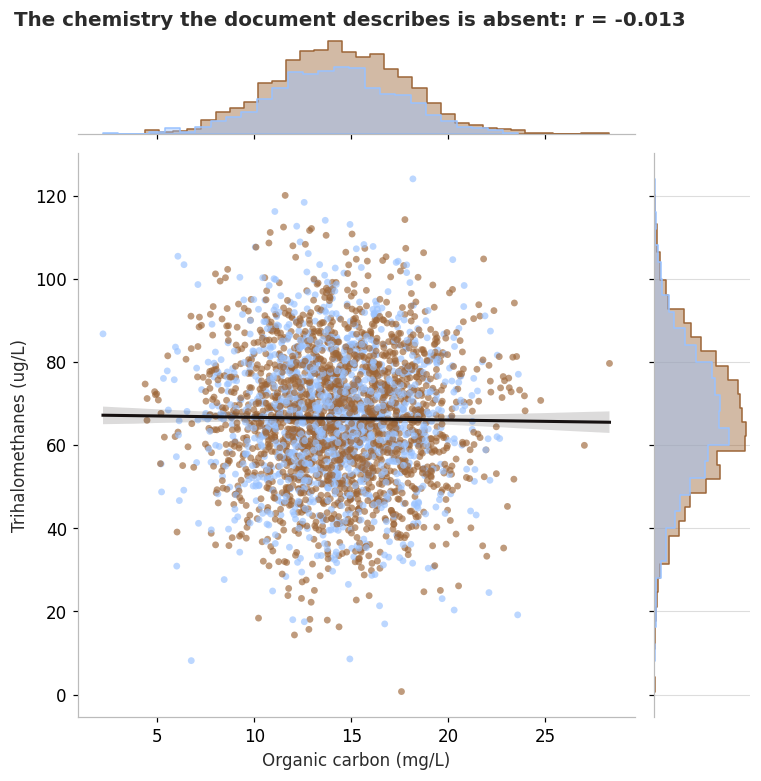

In [28]:
g = sns.JointGrid(data=df_no_missing, x="Organic_carbon", y="Trihalomethanes", height=7)

sns.scatterplot(
    data=df_no_missing, x="Organic_carbon", y="Trihalomethanes", hue="Potability",
    palette=CLASS_COLOR, alpha=0.65, s=20, linewidth=0, ax=g.ax_joint, legend=False,
)
sns.regplot(
    data=df_no_missing, x="Organic_carbon", y="Trihalomethanes",
    scatter=False, color=C["boundary"], ax=g.ax_joint,
    line_kws=dict(linewidth=2),
)
for cls in (0, 1):
    subset = df_no_missing[df_no_missing["Potability"] == cls]
    sns.histplot(x=subset["Organic_carbon"], element="step", fill=True, alpha=0.45,
                 color=CLASS_COLOR[cls], ax=g.ax_marg_x, legend=False)
    sns.histplot(y=subset["Trihalomethanes"], element="step", fill=True, alpha=0.45,
                 color=CLASS_COLOR[cls], ax=g.ax_marg_y, legend=False)

r_toc = df_no_missing["Organic_carbon"].corr(df_no_missing["Trihalomethanes"])
print(f"r(Organic_carbon, Trihalomethanes) = {r_toc:+.4f}")
g.ax_joint.set_xlabel("Organic carbon (mg/L)")
g.ax_joint.set_ylabel("Trihalomethanes (ug/L)")
g.ax_joint.grid(False)
g.figure.suptitle(
    f"The chemistry the document describes is absent: r = {r_toc:+.3f}",
    y=1.01, x=0.02, ha="left", fontsize=13, fontweight="semibold")
plt.savefig(FIGURE_DIR / "05-thm-vs-organic-carbon.png")
plt.show()

**Takeaway.** The regression line is flat — the correlation printed above the chart is
within 0.02 of zero. There is no dependence of trihalomethanes on organic carbon here.

I recorded that as a surprise in my first pass. It should not have been, and the reason
generalises to the whole file: **the columns were drawn independently of one another.** In
real water chemistry, hardness, conductivity and dissolved solids are close to three
measurements of the same underlying quantity and would correlate at 0.7 or above. The table
below shows what they do instead.

In [29]:
feature_corr = df_no_missing[FEATURES].corr()
off_diagonal = feature_corr.where(~np.eye(len(FEATURES), dtype=bool))

pairs = (off_diagonal.stack()
         .rename("r")
         .reset_index()
         .rename(columns={"level_0": "feature A", "level_1": "feature B"}))
pairs = pairs[pairs["feature A"] < pairs["feature B"]]
pairs["|r|"] = pairs["r"].abs()
pairs = pairs.sort_values("|r|", ascending=False)

print("Strongest feature-to-feature correlations in the file:")
print(pairs.head(5).drop(columns="|r|").round(3).to_string(index=False))
print(f"\nmedian |r| across all {len(pairs)} pairs: {pairs['|r|'].median():.3f}")
print("\nFor comparison, in real water chemistry Hardness / Conductivity / Solids "
      "would correlate at 0.7+.")
print(f"  here, Hardness vs Conductivity: "
      f"{df_no_missing['Hardness'].corr(df_no_missing['Conductivity']):+.3f}")
print(f"        Solids   vs Conductivity: "
      f"{df_no_missing['Solids'].corr(df_no_missing['Conductivity']):+.3f}")

Strongest feature-to-feature correlations in the file:
  feature A feature B      r
     Solids   Sulfate -0.170
   Hardness   Sulfate -0.118
     Solids        ph -0.097
   Hardness        ph  0.090
Chloramines    Solids -0.066

median |r| across all 36 pairs: 0.018

For comparison, in real water chemistry Hardness / Conductivity / Solids would correlate at 0.7+.
  here, Hardness vs Conductivity: -0.020
        Solids   vs Conductivity: +0.016


### Correlation with the target

This is the chart that prompted the notebook.

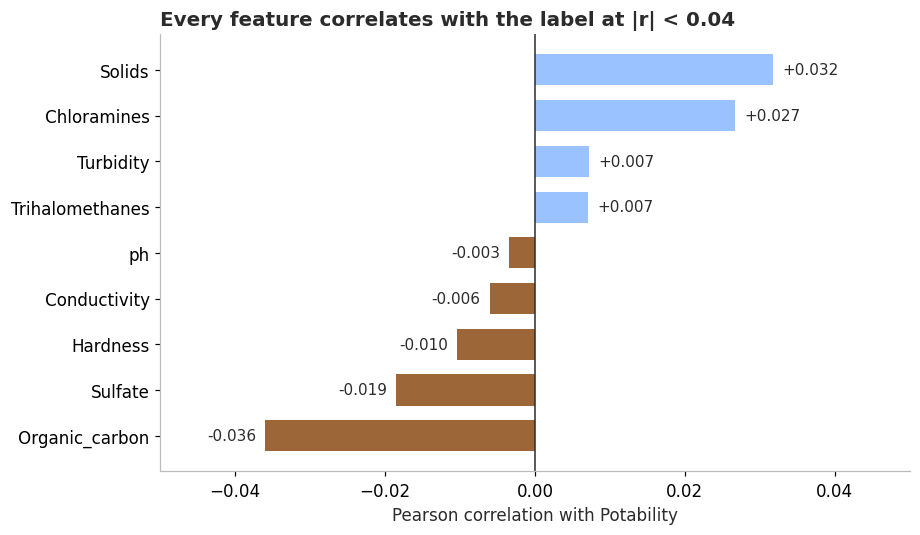

In [30]:
target_corr = (df_no_missing.corr(numeric_only=True)[TARGET]
               .drop(TARGET)
               .sort_values())

fig, ax = plt.subplots(figsize=(8.5, 5))
bar_colors = [C["potable"] if v >= 0 else C["not_potable"] for v in target_corr]
ax.barh(range(len(target_corr)), target_corr.values, color=bar_colors, height=0.68)

for i, value in enumerate(target_corr.values):
    ax.text(value + (0.0012 if value >= 0 else -0.0012), i, f"{value:+.3f}",
            va="center", ha="left" if value >= 0 else "right", fontsize=10)

ax.set_yticks(range(len(target_corr)), target_corr.index)
ax.axvline(0, color=C["text"], linewidth=1)
ax.set_xlim(-0.05, 0.05)
ax.set_xlabel("Pearson correlation with Potability")
ax.set_title("Every feature correlates with the label at |r| < 0.04")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "06-correlation-with-target.png")
plt.show()

**Takeaway — the correction the rest of this notebook rests on.**

The chart is accurate. My note beneath it — *"I am wondering why???"* — asked the right
question but implied the wrong conclusion, that there is nothing here to find.

A Pearson correlation between a feature and a binary label detects one specific thing: a
**linear, monotone, marginal** relationship. It is blind to three others, and this dataset
contains the third.

- **Non-monotone effects.** If potable water sits in the *middle* of a feature's range, the
  low and high ends push the correlation towards zero and cancel out.
- **Threshold effects.** A jump in the potable rate at one cut point barely moves a
  coefficient fitted across the whole range.
- **Interactions.** If the label depends on two features *jointly*, each one can be
  completely uninformative on its own.

The pH band from section 5 is an instance of the first, which is why its correlation is
+0.014. The next section is about the third.

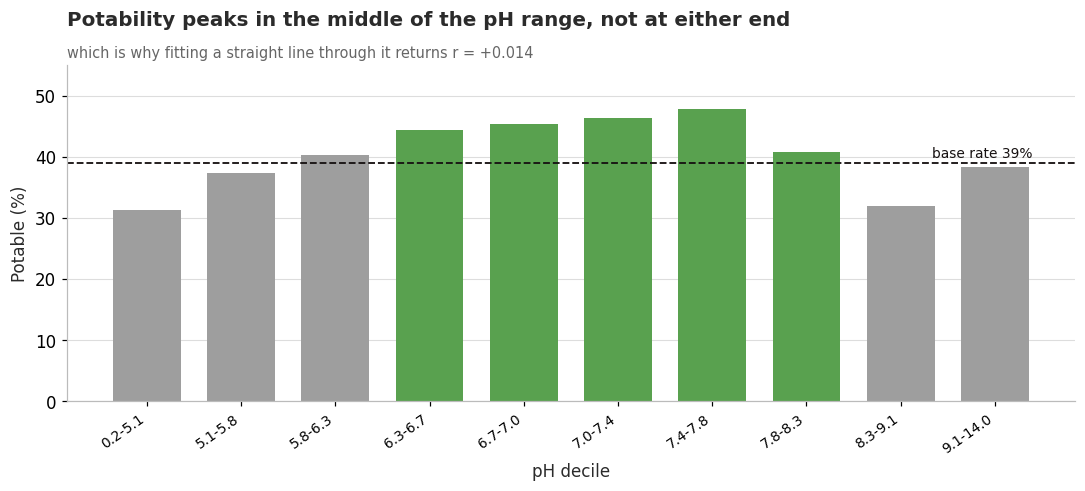

                size  potable %
ph                             
(0.226, 5.142]   202       31.2
(5.142, 5.841]   201       37.3
(5.841, 6.32]    201       40.3
(6.32, 6.705]    201       44.3
(6.705, 7.027]   201       45.3
(7.027, 7.4]     201       46.3
(7.4, 7.831]     201       47.8
(7.831, 8.31]    201       40.8
(8.31, 9.067]    201       31.8
(9.067, 14.0]    201       38.3


In [31]:
# pH is the worked example of a non-monotone effect: a real band effect, invisible to r.
ph_deciles = pd.qcut(complete_cases["ph"], 10)
by_decile = complete_cases.groupby(ph_deciles, observed=True)[TARGET].agg(["size", "mean"])

fig, ax = plt.subplots(figsize=(10, 4.6))
centres = [interval.mid for interval in by_decile.index]
inside_band = [ph_low <= c <= ph_high for c in centres]
bar_colors = [C["ok"] if ok else C["neutral"] for ok in inside_band]

ax.bar(range(len(by_decile)), by_decile["mean"] * 100, color=bar_colors, width=0.72)
ax.axhline(BASE_RATE * 100, color=C["boundary"], linestyle="--", linewidth=1.2)
ax.text(9.4, BASE_RATE * 100 + 0.8, f"base rate {BASE_RATE:.0%}",
        ha="right", fontsize=9, color=C["boundary"])

ax.set_xticks(range(len(by_decile)),
              [f"{i.left:.1f}-{i.right:.1f}" for i in by_decile.index],
              rotation=35, ha="right", fontsize=9)
ax.set_xlabel("pH decile")
ax.set_ylabel("Potable (%)")
ax.set_ylim(0, 55)
titled(ax, "Potability peaks in the middle of the pH range, not at either end",
       "which is why fitting a straight line through it returns r = +0.014")
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "07-ph-deciles.png")
plt.show()

print(by_decile.assign(**{"potable %": (by_decile["mean"] * 100).round(1)})
               .drop(columns="mean").to_string())

**Takeaway.** The potable rate climbs from 31% in the most acidic decile to 48% around
pH 7.4–7.8, then falls back to 32% by pH 8.3–9.1 — a genuine, sizeable **hump**. A straight
line fitted through it has almost no slope, which is exactly the +0.014 the bar chart
reported. The correlation was never wrong; it was answering a question about straight lines.

---
## 7. What the label is actually made of

If the label depends on no feature alone, the next candidate is a **pair**. For each of the
36 pairs among nine features I standardise both columns and correlate their product with
the label — a high value means the label depends on the two *jointly*, in a way neither
shows on its own.

In [32]:
standardised = complete_cases[FEATURES].apply(lambda s: (s - s.mean()) / s.std())

interactions = []
for i, a in enumerate(FEATURES):
    for b in FEATURES[i + 1:]:
        interactions.append({
            "pair": f"{a} x {b}",
            "feature A": a,
            "feature B": b,
            "r with Potability": (standardised[a] * standardised[b]).corr(complete_cases[TARGET]),
        })

interactions = pd.DataFrame(interactions)
interactions["|r|"] = interactions["r with Potability"].abs()
interactions = interactions.sort_values("|r|", ascending=False).reset_index(drop=True)

print("Strongest pairwise interactions (complete cases, n = "
      f"{len(complete_cases):,}):\n")
print(interactions.head(6)[["pair", "r with Potability"]].round(4).to_string(index=False))
print(f"\nmedian |r| across all {len(interactions)} pairs: "
      f"{interactions['|r|'].median():.4f}")
print(f"strongest single-feature |r| for comparison:        "
      f"{target_corr.abs().max():.4f}")

Strongest pairwise interactions (complete cases, n = 2,011):

                     pair  r with Potability
             ph x Sulfate            -0.2225
         ph x Chloramines             0.1721
         Solids x Sulfate            -0.1698
              ph x Solids             0.1266
     Solids x Chloramines            -0.0798
Sulfate x Trihalomethanes            -0.0669

median |r| across all 36 pairs: 0.0215
strongest single-feature |r| for comparison:        0.0360


**Takeaway.** `ph x Sulfate` correlates **−0.22** with the label: **six times** the
strongest single-feature correlation anywhere in the dataset (0.036), **ten times** the
median interaction (0.022), and **fifteen times** its own two ingredients (+0.015 and
−0.015).

An effect of that size at n = 2,011 is far beyond what multiple testing over 36 comparisons
could produce, and the next two sections show it is stable and reproduced by a model. The
label does depend on the features — in pairs.

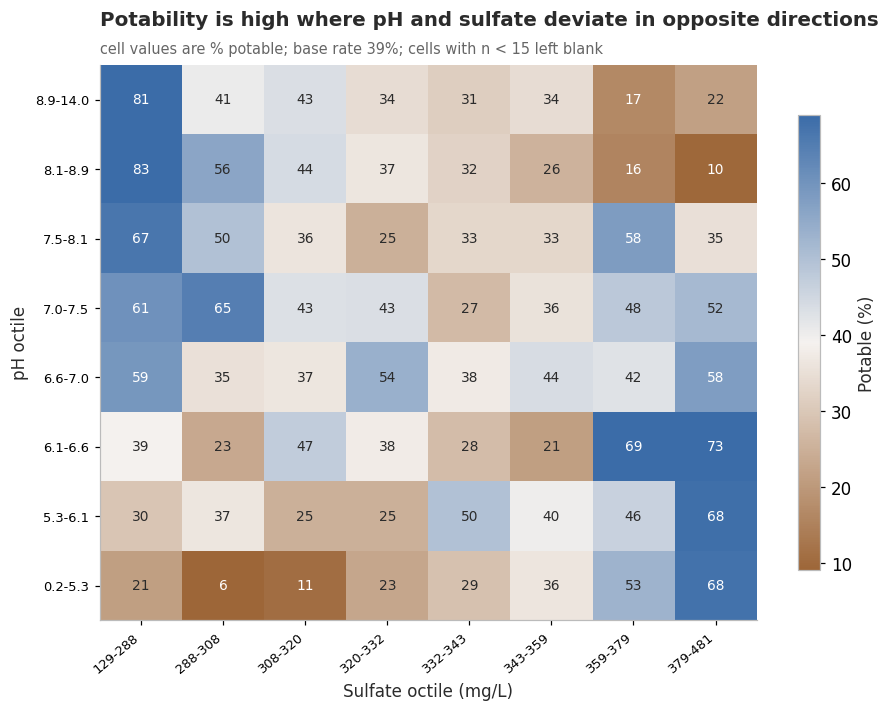

Corner blocks (2x2 octiles each).  Base rate 39.0%

  high pH + low sulfate    n = 113   potable  64.6%
  low pH + high sulfate    n = 141   potable  60.3%
  high pH + high sulfate   n = 120   potable  16.7%
  low pH + low sulfate     n = 125   potable  22.4%


In [33]:
def rate_grid(frame, feature_a, feature_b, bins=8, min_count=15):
    """Potable rate on a quantile grid of two features. Sparse cells -> NaN."""
    a_bin = pd.qcut(frame[feature_a], bins, labels=False, duplicates="drop")
    b_bin = pd.qcut(frame[feature_b], bins, labels=False, duplicates="drop")
    grouped = frame.groupby([a_bin, b_bin], observed=True)[TARGET].agg(["size", "mean"])
    rate = grouped["mean"].unstack() * 100
    count = grouped["size"].unstack()
    return rate.where(count >= min_count), count


def edge_labels(frame, feature, bins=8):
    edges = pd.qcut(frame[feature], bins, retbins=True, duplicates="drop")[1]
    return [f"{lo:.0f}-{hi:.0f}" if abs(hi) > 20 else f"{lo:.1f}-{hi:.1f}"
            for lo, hi in zip(edges[:-1], edges[1:])]


rate, count = rate_grid(complete_cases, "ph", "Sulfate")

fig, ax = plt.subplots(figsize=(8.6, 6.6))
im = ax.imshow(rate.values, cmap=DIV, vmin=BASE_RATE * 100 - 30, vmax=BASE_RATE * 100 + 30,
               origin="lower", aspect="auto")

for i in range(rate.shape[0]):
    for j in range(rate.shape[1]):
        value = rate.values[i, j]
        if np.isnan(value):
            continue
        ax.text(j, i, f"{value:.0f}", ha="center", va="center", fontsize=9,
                color="white" if abs(value - BASE_RATE * 100) > 18 else C["text"])

ax.set_xticks(range(rate.shape[1]), edge_labels(complete_cases, "Sulfate"),
              rotation=40, ha="right", fontsize=8.5)
ax.set_yticks(range(rate.shape[0]), edge_labels(complete_cases, "ph"), fontsize=8.5)
ax.set_xlabel("Sulfate octile (mg/L)")
ax.set_ylabel("pH octile")
titled(ax, "Potability is high where pH and sulfate deviate in opposite directions",
       f"cell values are % potable; base rate {BASE_RATE:.0%}; "
       "cells with n < 15 left blank")
ax.grid(False)
cbar = fig.colorbar(im, ax=ax, shrink=0.82)
cbar.set_label("Potable (%)")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "08-ph-sulfate-saddle.png")
plt.show()

# Corner blocks: 2x2 groups of octiles, so each figure rests on ~130 rows, not ~30.
ph_bin = pd.qcut(complete_cases["ph"], 8, labels=False)
sulfate_bin = pd.qcut(complete_cases["Sulfate"], 8, labels=False)
corners = {
    "high pH + low sulfate":  (ph_bin >= 6) & (sulfate_bin <= 1),
    "low pH + high sulfate":  (ph_bin <= 1) & (sulfate_bin >= 6),
    "high pH + high sulfate": (ph_bin >= 6) & (sulfate_bin >= 6),
    "low pH + low sulfate":   (ph_bin <= 1) & (sulfate_bin <= 1),
}
print(f"Corner blocks (2x2 octiles each).  Base rate {BASE_RATE:.1%}\n")
for label, mask in corners.items():
    print(f"  {label:24s} n = {mask.sum():3d}   potable "
          f"{complete_cases.loc[mask.values, TARGET].mean():6.1%}")

**Takeaway — this is the shape of the label.**

Each corner pools a 2×2 block of octiles, so every figure rests on roughly 130 samples
rather than 30:

| Corner | Potable |
|---|---|
| high pH + low sulfate | **64.6%** |
| low pH + high sulfate | **60.3%** |
| low pH + low sulfate | **22.4%** |
| high pH + high sulfate | **16.7%** |

The base rate is 39%. The two *opposite* corners run at roughly 62%, the two *matching*
corners at roughly 20% — a spread of more than 40 percentage points, from two columns that
individually correlate with the label at 0.015.

That is a **saddle**: potable when pH and sulfate deviate from their means in *opposite*
directions, not potable when they deviate the *same* way. Average that surface along either
axis and the highs and lows cancel, which is precisely why both marginal correlations sit
within 0.015 of zero and why the bar chart in section 6 looked empty.

Chemically this is backwards — low pH with high sulfate is the signature of acid drainage,
the *least* drinkable combination. With section 3, that confirms it describes the
generator, not water. It is still the correct description of the label.

In [34]:
# The same view for the other strong pairs, plus a control pair with no interaction.
pair_choices = [(row["feature A"], row["feature B"])
                for _, row in interactions.head(3).iterrows()]
pair_choices.append(tuple(interactions.iloc[-1][["feature A", "feature B"]]))

fig = go.Figure()
for index, (a, b) in enumerate(pair_choices):
    rate, count = rate_grid(complete_cases, a, b)
    fig.add_trace(go.Heatmap(
        z=rate.values,
        x=edge_labels(complete_cases, b),
        y=edge_labels(complete_cases, a),
        customdata=count.values,
        colorscale=[[0, C["not_potable"]], [0.5, "#F5F2EF"], [1, "#3B6CA8"]],
        zmid=BASE_RATE * 100, zmin=5, zmax=75,
        colorbar=dict(title="potable %", thickness=14),
        visible=(index == 0),
        hovertemplate=(a + " %{y}<br>" + b + " %{x}"
                       "<br>potable %{z:.0f}%<br>n = %{customdata}<extra></extra>"),
    ))

buttons = []
for index, (a, b) in enumerate(pair_choices):
    r_value = interactions.loc[
        (interactions["feature A"] == a) & (interactions["feature B"] == b),
        "r with Potability"].iloc[0]
    visible = [i == index for i in range(len(pair_choices))]
    tag = "control pair" if index == len(pair_choices) - 1 else f"rank {index + 1}"
    buttons.append(dict(
        label=f"{a} x {b}",
        method="update",
        args=[{"visible": visible},
              {"xaxis.title.text": f"{b} octile",
               "yaxis.title.text": f"{a} octile",
               "title.text": (f"Potable rate over {a} x {b}<br>"
                              f"<sup>{tag} of 36 &nbsp;|&nbsp; interaction r = "
                              f"{r_value:+.3f} &nbsp;|&nbsp; base rate "
                              f"{BASE_RATE:.0%} &nbsp;|&nbsp; cells with n &lt; 15 "
                              f"left blank</sup>")}],
    ))

a0, b0 = pair_choices[0]
r0 = interactions.iloc[0]["r with Potability"]
fig.update_layout(
    **PLOTLY_LAYOUT,
    height=600,
    xaxis_title=f"{b0} octile",
    yaxis_title=f"{a0} octile",
    title=dict(text=(f"Potable rate over {a0} x {b0}<br><sup>rank 1 of 36 &nbsp;|&nbsp; "
                     f"interaction r = {r0:+.3f} &nbsp;|&nbsp; base rate {BASE_RATE:.0%}"
                     f" &nbsp;|&nbsp; cells with n &lt; 15 left blank</sup>")),
    updatemenus=[dict(buttons=buttons, direction="down", showactive=True,
                      x=0.0, xanchor="left", y=1.18, yanchor="top",
                      bgcolor="white", bordercolor=C["grid"])],
)
fig.show()

**Takeaway.** The control pair at the bottom of the ranking shows what "no interaction"
looks like: a flat wash of cells near the 39% base rate, no structure in any direction. The
three real interactions each show a clear diagonal gradient. That contrast is the check
that the saddle is a property of the data and not of the binning.

In [35]:
# The simplest possible statement of the effect: same side, or opposite sides?
z_ph = standardised["ph"]
z_sulfate = standardised["Sulfate"]
interaction_term = z_ph * z_sulfate

side = np.where(interaction_term > 0, "same side of the mean", "opposite sides")
by_side = (complete_cases.assign(side=side)
           .groupby("side")[TARGET].agg(["size", "mean"]))
by_side["potable %"] = (by_side["mean"] * 100).round(1)

print(by_side.drop(columns="mean").to_string())
print(f"\nbase rate: {BASE_RATE:.1%}")
print(f"\nr(ph, Potability)                 = {complete_cases['ph'].corr(complete_cases[TARGET]):+.4f}")
print(f"r(Sulfate, Potability)            = {complete_cases['Sulfate'].corr(complete_cases[TARGET]):+.4f}")
print(f"r(z_ph * z_Sulfate, Potability)   = {interaction_term.corr(complete_cases[TARGET]):+.4f}")

                       size  potable %
side                                  
opposite sides          984       49.2
same side of the mean  1027       31.8

base rate: 39.0%

r(ph, Potability)                 = +0.0145
r(Sulfate, Potability)            = -0.0153
r(z_ph * z_Sulfate, Potability)   = -0.2225


**Takeaway.** Without the grid at all: when pH and sulfate sit on **opposite** sides of
their means, 49.2% of samples are potable; on the **same** side, 31.8%. One yes/no question
separates the classes by 17 percentage points, built from two columns that individually
separate them by less than one.

---
## 8. How much signal is there, in total?

A model comparison settles whether I have found something real or talked myself into a
pattern. Three things make it a fair test: five-fold cross-validation, a **dummy
classifier** as the stated baseline, and a **label-permutation null** — the same model
refitted on shuffled labels — to show what this many features and rows produce by chance
alone.

ROC AUC is the metric because the classes are unbalanced at 39/61, where accuracy would
reward a model that always predicts "not potable".

In [36]:
import warnings

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

X = complete_cases[FEATURES]
y = complete_cases[TARGET]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# Main effects plus every pairwise product, for a linear model that can see interactions.
X_interactions = X.copy()
for i, a in enumerate(FEATURES):
    for b in FEATURES[i + 1:]:
        X_interactions[f"{a}*{b}"] = standardised[a] * standardised[b]

candidates = {
    "Dummy (always 'not potable')": (
        make_pipeline(DummyClassifier(strategy="prior")), X),
    "Logistic regression, 9 features": (
        make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)), X),
    "Logistic regression + 36 interactions": (
        make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)), X_interactions),
    "Random forest, 9 features": (
        RandomForestClassifier(n_estimators=500, random_state=RANDOM_SEED, n_jobs=-1), X),
}

results = []
for name, (model, features) in candidates.items():
    scores = cross_val_score(model, features, y, cv=cv, scoring="roc_auc", n_jobs=-1)
    results.append({"model": name, "ROC AUC": scores.mean(), "sd": scores.std()})

scoreboard = pd.DataFrame(results).set_index("model").round(3)
display(scoreboard)

forest = RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1)
real_auc = cross_val_score(forest, X, y, cv=cv, scoring="roc_auc", n_jobs=-1).mean()

null_aucs = []
for _ in range(20):
    shuffled = pd.Series(rng.permutation(y.values), index=y.index)
    null_aucs.append(
        cross_val_score(forest, X, shuffled, cv=cv, scoring="roc_auc", n_jobs=-1).mean())
null_aucs = np.array(null_aucs)

print(f"\nLabel-permutation null, random forest, 20 shuffles:")
print(f"  real AUC        {real_auc:.3f}")
print(f"  null mean (sd)  {null_aucs.mean():.3f} ({null_aucs.std():.3f})")
print(f"  largest null    {null_aucs.max():.3f}")
print(f"  z               {(real_auc - null_aucs.mean()) / null_aucs.std():.1f}")

,ROC AUC,sd
model,,
Dummy (always 'not potable'),0.500,0.000
"Logistic regression, 9 features",0.482,0.020
Logistic regression + 36 interactions,0.683,0.023
"Random forest, 9 features",0.708,0.030



Label-permutation null, random forest, 20 shuffles:
  real AUC        0.708
  null mean (sd)  0.502 (0.014)
  largest null    0.531
  z               14.7


**Takeaway — there is real signal, and a linear model on the raw features cannot see any
of it.**

| Model | ROC AUC | What it can see |
|---|---|---|
| Dummy | 0.500 | nothing, by construction |
| Logistic regression, 9 features | 0.482 | linear marginal effects |
| Logistic regression + 36 interactions | 0.683 | linear effects **and** pairwise products |
| Random forest | 0.708 | arbitrary non-linear structure |

Logistic regression on the raw features scores **0.482**, fractionally *below* the dummy —
what cross-validation noise looks like when the true value is 0.5. That is the correlation
bar chart restated in another language; the two are blind in the same way.

Adding the 36 pairwise products to the same linear model lifts it to **0.683**, the
load-bearing result of the notebook. As a share of the distance from chance to the random
forest, the interactions recover **88%** of the forest's advantage (0.183 of 0.208) — so
the forest is not exploiting some deep non-linearity I cannot name. The remaining 0.025 is
real but small, and I am not going to claim to know what it is.

Shuffling the labels drops the forest to **0.502** (sd 0.014, maximum 0.531 over 20
shuffles), putting the real score roughly **15 standard deviations** above the null.

A sense of proportion: 0.708 is real but modest. Most of the label is unexplained by
anything in these nine columns, and the honest summary is that `Potability` is *mostly*
noise with a clear, reproducible interaction structure underneath it.

---
## 9. Conclusion

**What I found**

1. The file is generated, not measured: every non-null value distinct at 12–15 decimal
   places, 99.9% of samples above the document's limit for dissolved solids and 8% above
   seawater, and the nine columns mutually near-independent (median |r| = 0.02) where real
   chemistry would show 0.7 between hardness, conductivity and solids.
2. The missing values are missing completely at random with respect to the label
   (p = 0.16, 0.35, 0.20), which is what makes dropping and imputing rows defensible here.
3. Of the document's eight guideline bands, only the pH window separates the classes —
   43.9% potable inside against 35.6% outside. No sample satisfies all eight.
4. Every feature correlates with `Potability` at |r| < 0.035, and that is a true statement
   about **straight lines**, not about information. pH has a hump-shaped effect that a
   correlation coefficient averages away to +0.014.
5. The label is driven by an **interaction between pH and sulfate**: opposite sides of the
   mean, 49.2% potable; same side, 31.8%. The standardised product correlates −0.22, six
   times the strongest marginal correlation in the file.
6. A random forest reaches ROC AUC 0.708 against logistic regression's 0.482, and the same
   logistic regression handed the 36 pairwise products reaches 0.683 — **88% of the
   forest's advantage over chance is pairwise interaction**, not deeper structure.

**What surprised me.** The chart I treated as a dead end was the most informative plot in
my first pass. I had read "r ≈ 0" as "no relationship" when it means "no *linear marginal*
relationship", and the entire result was hiding in that gap. Second, my own imputer:
writing k-NN by hand was worthwhile, but what it taught me only appeared when I measured it
— `Solids` supplied 98% of an unscaled Manhattan distance, so nine-feature k-NN was
one-feature k-NN.

**Limitations**

- The data is synthetic, so every finding describes the generator, not drinking water. The
  pH–sulfate saddle is chemically backwards, which is itself evidence for this.
- The interaction search tested 36 pairs and I report the largest. The rank ordering below
  the top three should not be over-read.
- The modelling uses complete cases, 2,011 of 3,276 rows.
- I never identified the generating rule itself, only its shape.

**What I would do next**

- Fit on the two-way interaction structure alone and check whether the residual is
  genuinely unstructured — that would say the saddle is the *whole* rule rather than the
  largest part of it.
- Test three-way interactions over the five features carrying non-zero permutation
  importance, to see whether AUC moves past 0.71.
- Re-run the guideline-band analysis against the WHO's published limits rather than the
  project document's.